# Προσέγγιση 2: Handcrafted Feature Engineering

Αυτό το notebook υλοποιεί τη **δεύτερη και κύρια προσέγγιση** του project. Αντί να τροφοδοτούμε τους ταξινομητές με raw flattened windows, εξάγουμε ένα διάνυσμα **63 χαρακτηριστικών** από κάθε παράθυρο — στατιστικά πεδίου χρόνου και συχνότητας — και μετά εφαρμόζουμε feature selection για να κρατήσουμε μόνο τα 15 πιο διακριτικά.

Ροή εργασίας:
1. Φόρτωση δεδομένων & preprocessing
2. Feature extraction (63 features/window)
3. Session-based split
4. Baseline αξιολόγηση (63 features)
5. Feature selection με Pearson correlation + RF importance (top 15)
6. Σύγκριση με PCA (95% variance)
7. Βελτιστοποίηση με Grid Search


## Imports & Σύνδεση στη MongoDB

Εισάγουμε τις βιβλιοθήκες που χρειαζόμαστε: `sklearn` για τους ταξινομητές, `pymongo` για τη βάση, και τις custom `utils` συναρτήσεις του project.

In [1]:
import os
import yaml
import pymongo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from utils import apply_filter, sliding_window_pd

config_path = os.path.join(os.getcwd(), "config.yml")
with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

client = pymongo.MongoClient(config["client"])
db = client[config["db"]]
coll = db[config["col"]]

## Ορισμός Συναρτήσεων Preprocessing & Feature Extraction

### `process_sensor_data`
Ίδια λογική με το windowed notebook: trim τελευταίων δειγμάτων, Z-score outlier removal και linear interpolation.

### `extract_features`
Εξάγει **63 χαρακτηριστικά** από κάθε παράθυρο:

**Cross-channel (3 features)** — υπολογίζονται από τους 3 άξονες επιταχυνσιόμετρου:
- `acc_vm_mean`: μέσος όρος του Vector Magnitude `√(x²+y²+z²)` — μέτρο συνολικής κίνησης
- `acc_vm_std`: τυπική απόκλιση του VM
- `acc_sma`: Signal Magnitude Area — άθροισμα απόλυτων τιμών, robust ως προς τον προσανατολισμό

**Ανά άξονα (6 axes × 10 features = 60 features):**
- *Time-domain (7):* mean, std, min, max, median, range, zero-crossing rate
- *Frequency-domain (3) μέσω FFT:* spectral energy, dominant frequency index, spectral entropy

> Η spectral entropy μετράει πόσο «διεσπαρμένη» είναι η ενέργεια στο φάσμα. Χαμηλή entropy = μία κυρίαρχη συχνότητα (π.χ. swipe), υψηλή = διάχυτη ενέργεια (π.χ. texting).

In [2]:
def process_sensor_data(df, trim_size=100, z_threshold=3):
    df_trimmed = df.iloc[:-trim_size].copy()
    for col_name in df_trimmed.columns:
        mean_val = df_trimmed[col_name].mean()
        std_val = df_trimmed[col_name].std()
        z_scores = (df_trimmed[col_name] - mean_val) / std_val
        df_trimmed.loc[np.abs(z_scores) > z_threshold, col_name] = np.nan
        df_trimmed[col_name] = df_trimmed[col_name].interpolate(method='linear')
        df_trimmed[col_name] = df_trimmed[col_name].ffill().bfill()
    return df_trimmed

def extract_features(window_df):
    features = []
    
    acc_cols = [c for c in window_df.columns if 'acc' in c]
    if len(acc_cols) == 3:
        acc_vals = window_df[acc_cols].values
        vm = np.sqrt(np.sum(acc_vals**2, axis=1))
        sma = np.mean(np.sum(np.abs(acc_vals), axis=1))
        features.extend([np.mean(vm), np.std(vm), sma])
        
    for col in window_df.columns:
        values = window_df[col].values
        
        mean_val = np.mean(values)
        std_val = np.std(values)
        min_val = np.min(values)
        max_val = np.max(values)
        median_val = np.median(values)
        range_val = max_val - min_val
        zcr_val = np.mean(np.diff(values > mean_val) != 0)
        
        features.extend([mean_val, std_val, min_val, max_val, median_val, range_val, zcr_val])
        
        fft_vals = np.abs(np.fft.rfft(values))
        fft_energy = np.sum(fft_vals**2)
        dom_freq_idx = np.argmax(fft_vals)
        
        psd = (fft_vals**2) / (fft_energy + 1e-9)
        spectral_entropy = -np.sum(psd * np.log2(psd + 1e-9))
        
        features.extend([fft_energy, dom_freq_idx, spectral_entropy])
        
    return features

## Preprocessing, Sliding Window & Session-Based Split

Για κάθε εγγραφή στη MongoDB:
1. Φορτώνουμε τα δεδομένα και τα καθαρίζουμε με `process_sensor_data`
2. Εφαρμόζουμε το Butterworth low-pass φίλτρο
3. Κόβουμε σε παράθυρα με `sliding_window_pd`
4. Για κάθε παράθυρο εξάγουμε τα 63 features με `extract_features`
5. Αποδίδουμε το παράθυρο στο **test** (session 5) ή στο **train** (sessions 1–4)

Στο τέλος φτιάχνουμε και τον πίνακα `df_train_features` με τα ονόματα των features για χρήση στο feature selection, καθώς και το label encoding και τη StandardScaler κανονικοποίηση.

In [3]:
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
session_tracker = {}

order = config["filter"]["order"]
wn = config["filter"]["wn"]
window_size = config["sliding_window"]["ws"]
overlap = config["sliding_window"]["overlap"]

for doc in coll.find({}):
    gesture = doc.get("gesture_id")
    user = doc.get("user")
    
    key = f"{user}_{gesture}"
    session_tracker[key] = session_tracker.get(key, 0) + 1
    current_session = session_tracker[key]
    
    df = pd.DataFrame(doc["data"])
    df_clean = process_sensor_data(df)
    df_filtered = df_clean.apply(apply_filter, args=(order, wn, "lowpass"))
    windows = sliding_window_pd(df_filtered, ws=window_size, overlap=overlap, print_stats=False)
    
    for window in windows:
        window_features = extract_features(window)
        if current_session == 5:
            X_test_list.append(window_features)
            y_test_list.append(gesture)
        else:
            X_train_list.append(window_features)
            y_train_list.append(gesture)

X_train_raw = np.array(X_train_list)
X_test_raw = np.array(X_test_list)
y_train_raw = np.array(y_train_list)
y_test_raw = np.array(y_test_list)

feature_names = ["acc_vm_mean", "acc_vm_std", "acc_sma"]
sensor_cols = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]
stat_names = ["mean", "std", "min", "max", "median", "range", "zcr", "fft_energy", "dom_freq", "spectral_entropy"]
for col in sensor_cols:
    for stat in stat_names:
        feature_names.append(f"{col}_{stat}")

df_train_features = pd.DataFrame(X_train_raw, columns=feature_names)

le = LabelEncoder()
le.fit(np.concatenate((y_train_raw, y_test_raw)))
y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

## Ορισμός Συνάρτησης Αξιολόγησης

Η `evaluate_models` εκπαιδεύει RandomForest, SVM και KNN με default παραμέτρους και τυπώνει το classification report για κάθε έναν. Τη χρησιμοποιούμε επανειλημμένα για να συγκρίνουμε τα αποτελέσματα σε διαφορετικά σύνολα features (full 63, top 15, PCA).

In [4]:
from sklearn.metrics import classification_report

def evaluate_models(X_tr, y_tr, X_te, y_te):
    models = {
        "RandomForest": RandomForestClassifier(random_state=42),
        "SVM": SVC(random_state=42),
        "KNN": KNeighborsClassifier()
    }
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        print(f"=================== {name} Classification Report ===================")
        print(classification_report(y_te, y_pred, target_names=le.classes_, digits=4))
        print("\n")

## Baseline: Αξιολόγηση με Όλα τα Features (63 dimensions)

Πρώτα τρέχουμε τους classifiers πάνω στο **πλήρες** feature set για να πάρουμε baseline αποτελέσματα. Αυτά θα τα συγκρίνουμε με τα αποτελέσματα μετά το feature selection.

In [5]:
print("--- Full Feature Baseline Validation ---")
evaluate_models(X_train, y_train, X_test, y_test)

--- Full Feature Baseline Validation ---
=================== RandomForest Classification Report ===================
                   precision    recall  f1-score   support

scroll-down-index     0.7607    0.4564    0.5705       195
  scroll-up-index     0.6010    0.5918    0.5964       196
 swipe-left-index     0.9524    0.9184    0.9351       196
swipe-right-index     0.8044    0.9646    0.8773       226
   texting-single     0.7577    0.9348    0.8370       184

         accuracy                         0.7773       997
        macro avg     0.7752    0.7732    0.7632       997
     weighted avg     0.7764    0.7773    0.7660       997



=================== SVM Classification Report ===================
                   precision    recall  f1-score   support

scroll-down-index     0.8324    0.7897    0.8105       195
  scroll-up-index     0.6813    0.6327    0.6561       196
 swipe-left-index     0.9153    0.8265    0.8686       196
swipe-right-index     0.8782    0.9248    0.9

## Feature Selection — Βήμα 1: Pearson Correlation Filter

Με 63 features υπάρχει μεγάλος κίνδυνος **πολυσυγγραμμικότητας** (collinearity): πολλά features μετράνε ουσιαστικά το ίδιο πράγμα. Αυτό βλάπτει την απόδοση και αυξάνει τον χρόνο εκπαίδευσης.

Υπολογίζουμε τον **Pearson correlation matrix** μεταξύ όλων των features **μόνο στο training set** (δεν χρησιμοποιούμε ποτέ το test για selection). Αφαιρούμε κάθε feature που έχει correlation > 0.95 με κάποιο άλλο.

Αποτέλεσμα: από 63 features κρατάμε χαμηλότερο αριθμό αφαιρώντας τα 39 redundant.

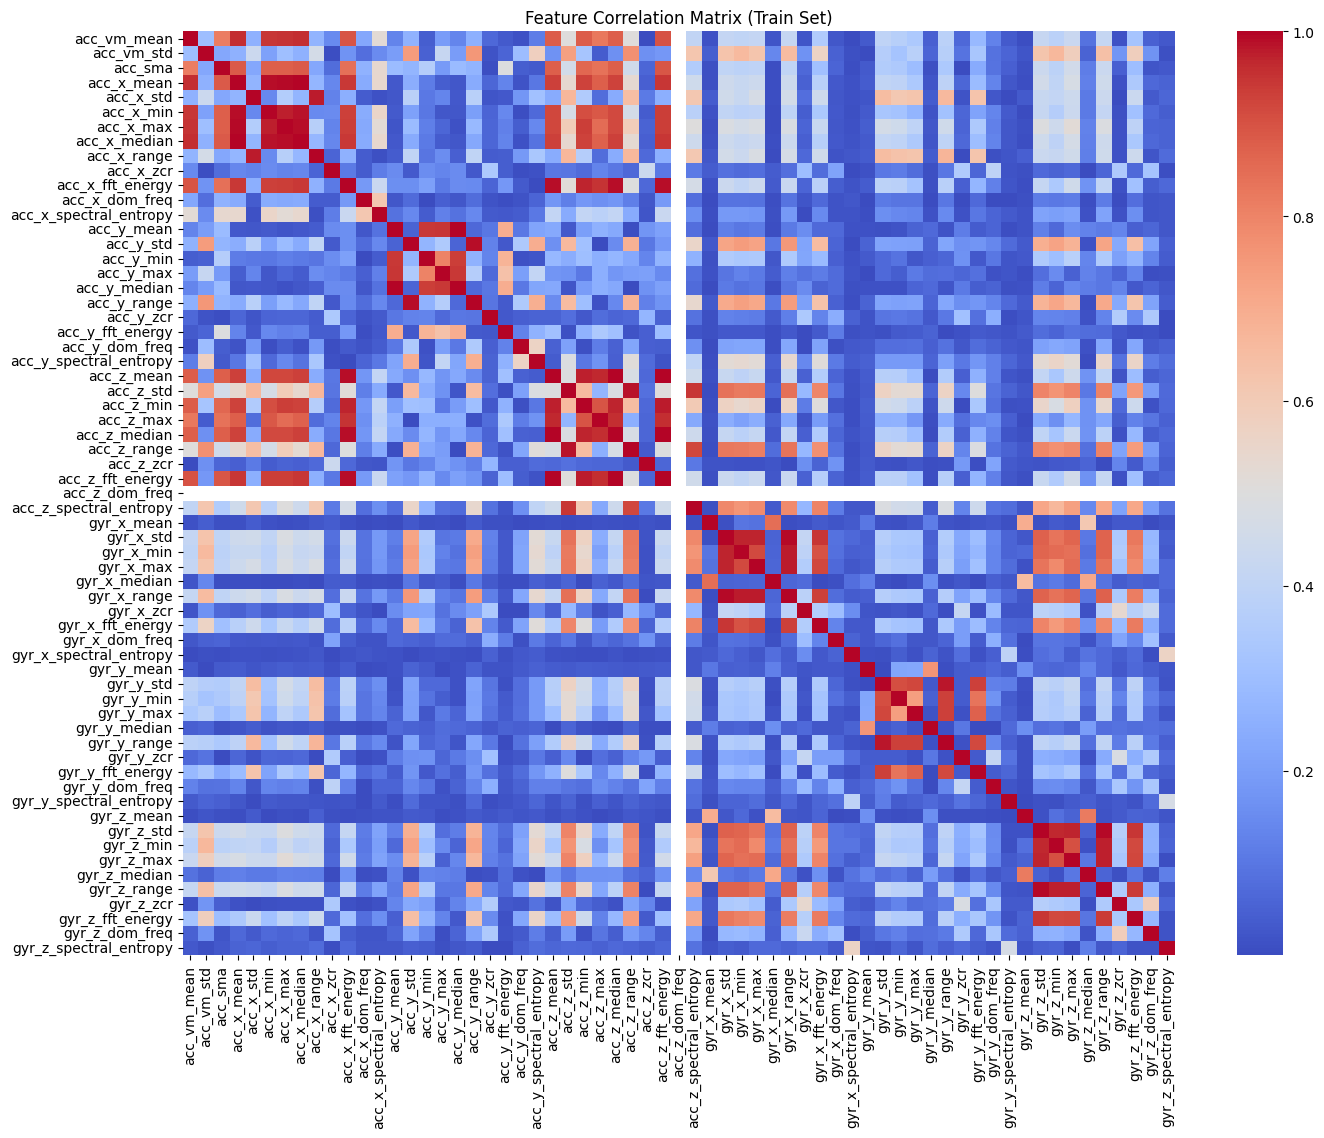

Features removed due to collinearity: 20
Features remaining: 43


In [6]:
corr_matrix = df_train_features.corr().abs()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix (Train Set)")
plt.show()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

keep_indices = [i for i, col in enumerate(feature_names) if col not in to_drop]

X_train_filtered = X_train[:, keep_indices]
X_test_filtered = X_test[:, keep_indices]

print(f"Features removed due to collinearity: {len(to_drop)}")
print(f"Features remaining: {X_train_filtered.shape[1]}")

## Feature Selection — Βήμα 2: RandomForest Feature Importance (Top 15)

Μετά το correlation filter, εκπαιδεύουμε ένα Random Forest αποκλειστικά για να μετρήσουμε τη **σημαντικότητα** κάθε feature (feature importance = πόσο κάθε feature βοηθά στην μείωση της αβεβαιότητας στα δέντρα αποφάσεων).

Κρατάμε τα **top 15** πιο διακριτικά features και αξιολογούμε τους classifiers πάνω σε αυτό το συμπιεσμένο feature space.

> Η μείωση από 63 (ή και λιγότερα μετά το correlation step) σε 15 features αντιμετωπίζει το **curse of dimensionality** και κάνει τα μοντέλα πιο γρήγορα και καλύτερα generalizable.

In [7]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_filtered, y_train)

importances = rf_selector.feature_importances_
indices = np.argsort(importances)[-15:] 

X_train_fs = X_train_filtered[:, indices]
X_test_fs = X_test_filtered[:, indices]

print("--- Validation (Feature Selection - Top 15) ---")
evaluate_models(X_train_fs, y_train, X_test_fs, y_test)

--- Validation (Feature Selection - Top 15) ---
=================== RandomForest Classification Report ===================
                   precision    recall  f1-score   support

scroll-down-index     0.7952    0.6769    0.7313       195
  scroll-up-index     0.6744    0.7398    0.7056       196
 swipe-left-index     0.9448    0.8724    0.9072       196
swipe-right-index     0.9322    0.9735    0.9524       226
   texting-single     0.8593    0.9293    0.8930       184

         accuracy                         0.8415       997
        macro avg     0.8412    0.8384    0.8379       997
     weighted avg     0.8437    0.8415    0.8408       997



=================== SVM Classification Report ===================
                   precision    recall  f1-score   support

scroll-down-index     0.7413    0.7641    0.7525       195
  scroll-up-index     0.7363    0.6837    0.7090       196
 swipe-left-index     0.9432    0.8469    0.8925       196
swipe-right-index     0.9513    0.9513

## Εναλλακτική Μείωση Διαστάσεων: PCA

Ως σύγκριση, εφαρμόζουμε **PCA** κρατώντας τόσα components όσα χρειάζονται για να διατηρηθεί το 95% της variance.

Αναμένουμε:
- SVM και KNN να διατηρούν καλή απόδοση (γεωμετρικής φύσης, δουλεύουν καλά στον νέο χώρο)
- RandomForest να υποβαθμιστεί σημαντικά — το PCA παράγει **αφηρημένους γραμμικούς συνδυασμούς** features που χάνουν τη φυσική τους ερμηνεία, καθιστώντας τους ορθογώνιους κόμβους αποφάσεων αναποτελεσματικούς.

In [8]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("--- Validation (PCA - 95% Variance) ---")
evaluate_models(X_train_pca, y_train, X_test_pca, y_test)

--- Validation (PCA - 95% Variance) ---
=================== RandomForest Classification Report ===================
                   precision    recall  f1-score   support

scroll-down-index     0.7770    0.5897    0.6706       195
  scroll-up-index     0.4780    0.5000    0.4888       196
 swipe-left-index     0.8311    0.6276    0.7151       196
swipe-right-index     0.7952    0.8761    0.8337       226
   texting-single     0.6154    0.8261    0.7053       184

         accuracy                         0.6881       997
        macro avg     0.6993    0.6839    0.6827       997
     weighted avg     0.7032    0.6881    0.6870       997



=================== SVM Classification Report ===================
                   precision    recall  f1-score   support

scroll-down-index     0.8280    0.7897    0.8084       195
  scroll-up-index     0.6497    0.5867    0.6166       196
 swipe-left-index     0.9266    0.8367    0.8794       196
swipe-right-index     0.8697    0.9159    0.89

## Βελτιστοποίηση Υπερπαραμέτρων με Grid Search

Εκτελούμε Grid Search με 5-fold cross-validation πάνω στο **βέλτιστο feature set (top 15)** για τους τρεις classifiers:

- **RandomForest:** Δοκιμάζουμε `n_estimators` ∈ {50,100,200} και `max_depth` ∈ {None,10,20}
- **SVM:** Δοκιμάζουμε `C` ∈ {0.1,1,10} και `kernel` ∈ {linear, rbf}
- **KNN:** Δοκιμάζουμε `n_neighbors` ∈ {3,5,7} και `weights` ∈ {uniform, distance}

Το CV score είναι συντηρητικό γιατί εκπαιδεύει κάθε φορά σε 80% των sessions. Τα τελικά test accuracies (Session 5) αναμένεται να είναι υψηλότερα.

In [9]:
X_train_best = X_train_fs
X_test_best = X_test_fs

models_to_tune = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]}
    },
    "SVM": {
        "model": SVC(random_state=42),
        "params": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": [3, 5, 7], "weights": ["uniform", "distance"]}
    }
}

for name, entry in models_to_tune.items():
    print(f"--- Grid Search: {name} ---")
    grid = GridSearchCV(entry["model"], entry["params"], cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train_best, y_train)
    print(f"Best Params: {grid.best_params_}")
    print(f"Best Score: {grid.best_score_:.4f}\n")

--- Grid Search: RandomForest ---
Best Params: {'max_depth': None, 'n_estimators': 200}
Best Score: 0.7769

--- Grid Search: SVM ---
Best Params: {'C': 10, 'kernel': 'rbf'}
Best Score: 0.7898

--- Grid Search: KNN ---
Best Params: {'n_neighbors': 3, 'weights': 'uniform'}
Best Score: 0.7798

